# PaySim EDA and Preprocessing

This notebook performs:
1. Exploratory Data Analysis (EDA) on the raw PaySim dataset
2. Preprocessing and feature engineering
3. Temporal train/test split and artifact export for downstream pipelines

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
RAW_CSV = ROOT / 'data' / 'raw' / 'PaySim' / 'PS_20174392719_1491204439457_log.csv'
PROCESSED = ROOT / 'data' / 'processed' / 'paysim'
FEATURES = ROOT / 'data' / 'features' / 'paysim'
EDA_FIGURES = ROOT / 'notebooks' / 'eda_outputs' / 'figures'
EDA_TABLES = ROOT / 'notebooks' / 'eda_outputs' / 'tables'
REPORT_PATH = ROOT / 'notebooks' / 'eda_outputs' / 'PAYSIM_EDA_SUMMARY_REPORT.txt'

for path in [PROCESSED, FEATURES, EDA_FIGURES, EDA_TABLES]:
    path.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 50)

print(f'ROOT: {ROOT}')
print(f'Raw dataset: {RAW_CSV}')

ROOT: d:\Mtech\Main project and Thesis\Federated-learning\ml-agentic-platform
Raw dataset: d:\Mtech\Main project and Thesis\Federated-learning\ml-agentic-platform\data\raw\PaySim\PS_20174392719_1491204439457_log.csv


In [2]:
df = pd.read_csv(RAW_CSV)
print(f'Loaded PaySim shape: {df.shape}')
print('Columns:', df.columns.tolist())

overview = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing_pct': (df.isna().mean() * 100).round(4),
    'n_unique': df.nunique(dropna=False)
}).sort_values(['missing_pct', 'n_unique'], ascending=[False, False])
overview.to_csv(EDA_TABLES / 'paysim_column_overview.csv')

print('Top rows:')
display(df.head(5))
display(overview.head(20))

Loaded PaySim shape: (6362620, 11)
Columns: ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']
Top rows:


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


,dtype,missing_pct,n_unique
nameOrig,str,0.0,6353307
amount,float64,0.0,5316900
oldbalanceDest,float64,0.0,3614697
newbalanceDest,float64,0.0,3555499
nameDest,str,0.0,2722362
newbalanceOrig,float64,0.0,2682586
oldbalanceOrg,float64,0.0,1845844
step,int64,0.0,743
type,str,0.0,5
isFraud,int64,0.0,2


In [3]:
# Core EDA tables
fraud_rate = df['isFraud'].mean()
flagged_rate = df['isFlaggedFraud'].mean()

type_distribution = df['type'].value_counts(dropna=False).rename_axis('type').reset_index(name='count')
type_distribution['pct'] = (type_distribution['count'] / len(df) * 100).round(4)
type_distribution.to_csv(EDA_TABLES / 'paysim_type_distribution.csv', index=False)

fraud_by_type = df.groupby('type', as_index=False).agg(
    total_transactions=('isFraud', 'size'),
    fraud_transactions=('isFraud', 'sum'),
    mean_amount=('amount', 'mean'),
    median_amount=('amount', 'median')
)
fraud_by_type['fraud_rate_pct'] = (fraud_by_type['fraud_transactions'] / fraud_by_type['total_transactions'] * 100).round(4)
fraud_by_type = fraud_by_type.sort_values('fraud_rate_pct', ascending=False)
fraud_by_type.to_csv(EDA_TABLES / 'paysim_fraud_by_type.csv', index=False)

step_fraud = df.groupby('step', as_index=False).agg(
    total_transactions=('isFraud', 'size'),
    fraud_transactions=('isFraud', 'sum'),
    avg_amount=('amount', 'mean')
)
step_fraud['fraud_rate_pct'] = (step_fraud['fraud_transactions'] / step_fraud['total_transactions'] * 100).round(6)
step_fraud.to_csv(EDA_TABLES / 'paysim_fraud_by_step.csv', index=False)

amount_quantiles = df['amount'].quantile([0.0, 0.25, 0.5, 0.75, 0.9, 0.99, 1.0]).rename('amount_quantile').to_frame()
amount_quantiles.to_csv(EDA_TABLES / 'paysim_amount_quantiles.csv')

numeric_summary = df[['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']].describe().T
numeric_summary.to_csv(EDA_TABLES / 'paysim_numeric_summary.csv')

print(f'Fraud rate: {fraud_rate:.4%}')
print(f'Flagged fraud rate: {flagged_rate:.6%}')
display(fraud_by_type)

Fraud rate: 0.1291%
Flagged fraud rate: 0.000251%


,type,total_transactions,fraud_transactions,mean_amount,median_amount,fraud_rate_pct
4,TRANSFER,532909,4097,910647.009645,486308.390,0.7688
1,CASH_OUT,2237500,4116,176273.964346,147072.185,0.1840
0,CASH_IN,1399284,0,168920.242004,143427.710,0.0000
2,DEBIT,41432,0,5483.665314,3048.990,0.0000
3,PAYMENT,2151495,0,13057.604660,9482.190,0.0000


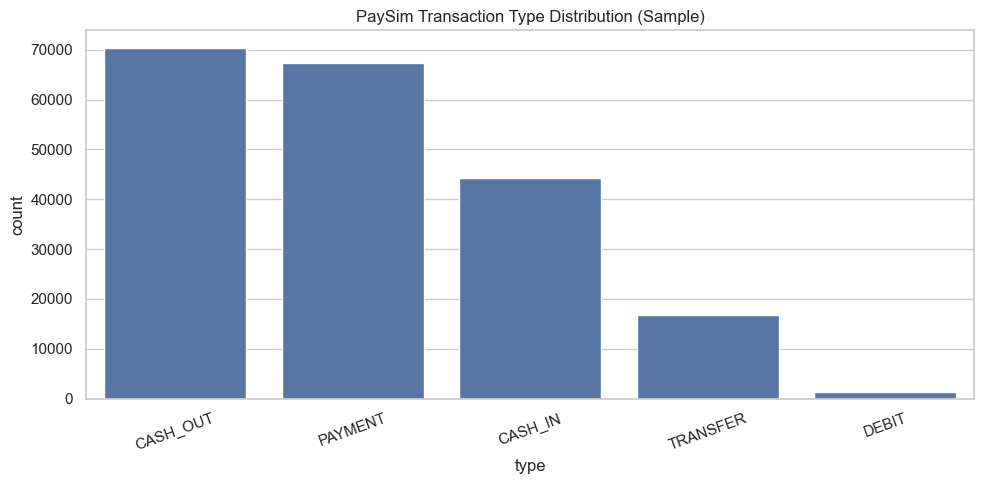

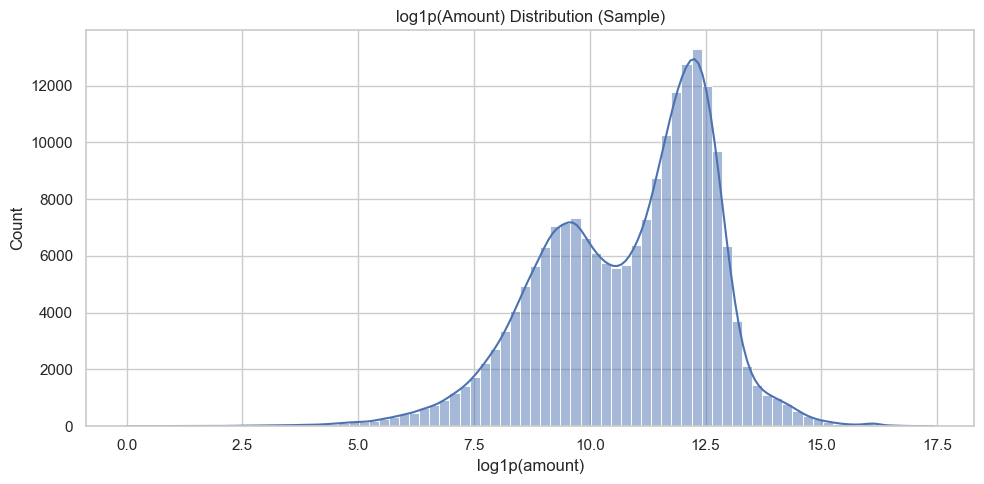

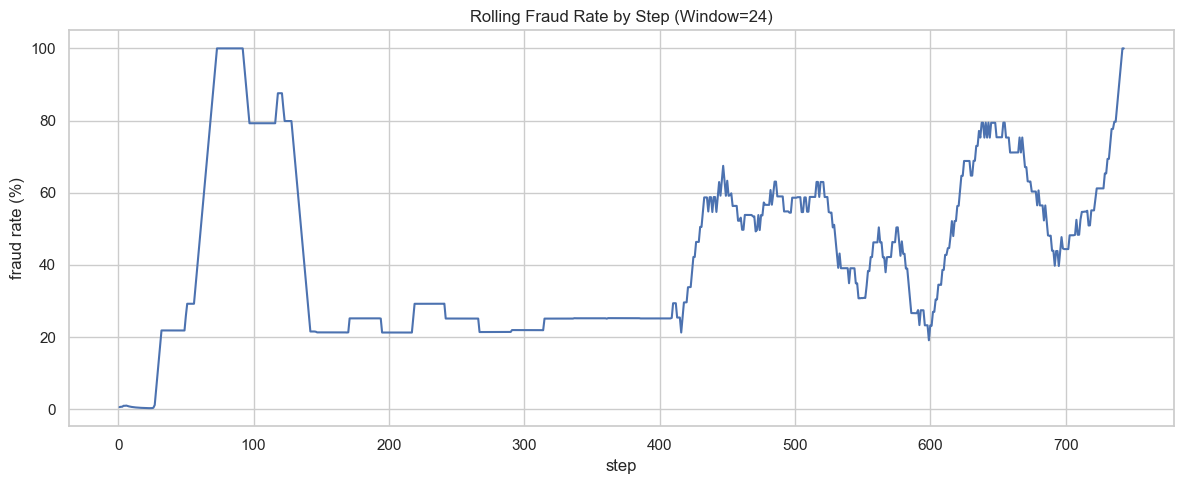

In [4]:
# Use a sample for plotting to keep plotting memory/time reasonable on very large data
sample_n = min(200_000, len(df))
plot_df = df.sample(sample_n, random_state=42)

plt.figure(figsize=(10, 5))
sns.countplot(data=plot_df, x='type', order=plot_df['type'].value_counts().index)
plt.title('PaySim Transaction Type Distribution (Sample)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(EDA_FIGURES / 'paysim_type_distribution.png', dpi=140)
plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(np.log1p(plot_df['amount']), bins=80, kde=True)
plt.title('log1p(Amount) Distribution (Sample)')
plt.xlabel('log1p(amount)')
plt.tight_layout()
plt.savefig(EDA_FIGURES / 'paysim_amount_log_distribution.png', dpi=140)
plt.show()

line_df = step_fraud.copy()
line_df['rolling_fraud_rate_pct'] = line_df['fraud_rate_pct'].rolling(24, min_periods=1).mean()

plt.figure(figsize=(12, 5))
plt.plot(line_df['step'], line_df['rolling_fraud_rate_pct'])
plt.title('Rolling Fraud Rate by Step (Window=24)')
plt.xlabel('step')
plt.ylabel('fraud rate (%)')
plt.tight_layout()
plt.savefig(EDA_FIGURES / 'paysim_rolling_fraud_rate.png', dpi=140)
plt.show()

In [5]:
summary_lines = [
    '=' * 72,
    'PAYSIM - EDA SUMMARY REPORT',
    '=' * 72,
    f'Total rows: {len(df):,}',
    f'Total columns: {df.shape[1]}',
    f'Fraud rate: {fraud_rate:.4%}',
    f'Flagged fraud rate: {flagged_rate:.6%}',
    '',
    'Top fraud-prone transaction types:',
]

for _, row in fraud_by_type.head(5).iterrows():
    summary_lines.append(
        f"  - {row['type']}: fraud_rate={row['fraud_rate_pct']:.4f}% | total={int(row['total_transactions']):,}"
    )

summary_lines.extend([
    '',
    'Recommended preprocessing applied in this notebook:',
    '  - Temporal split by step (80/20)',
    '  - Log transform for amount',
    '  - Balance consistency error features',
    '  - One-hot encoding for transaction type',
    '  - Median imputation for numeric columns',
    '=' * 72,
])

report_text = '\n'.join(summary_lines)
print(report_text)
REPORT_PATH.write_text(report_text, encoding='utf-8')
print(f'\nReport saved to: {REPORT_PATH}')

PAYSIM - EDA SUMMARY REPORT
Total rows: 6,362,620
Total columns: 11
Fraud rate: 0.1291%
Flagged fraud rate: 0.000251%

Top fraud-prone transaction types:
  - TRANSFER: fraud_rate=0.7688% | total=532,909
  - CASH_OUT: fraud_rate=0.1840% | total=2,237,500
  - CASH_IN: fraud_rate=0.0000% | total=1,399,284
  - DEBIT: fraud_rate=0.0000% | total=41,432
  - PAYMENT: fraud_rate=0.0000% | total=2,151,495

Recommended preprocessing applied in this notebook:
  - Temporal split by step (80/20)
  - Log transform for amount
  - Balance consistency error features
  - One-hot encoding for transaction type
  - Median imputation for numeric columns

Report saved to: d:\Mtech\Main project and Thesis\Federated-learning\ml-agentic-platform\notebooks\eda_outputs\PAYSIM_EDA_SUMMARY_REPORT.txt


In [6]:
proc = df.copy()

# Feature engineering
proc['log_amount'] = np.log1p(proc['amount'])
proc['orig_balance_error'] = (proc['oldbalanceOrg'] - proc['amount'] - proc['newbalanceOrig']).abs()
proc['dest_balance_error'] = (proc['oldbalanceDest'] + proc['amount'] - proc['newbalanceDest']).abs()

# Cyclical time features; step is hour-like in PaySim simulator
proc['step_sin'] = np.sin(2 * np.pi * proc['step'] / 24.0)
proc['step_cos'] = np.cos(2 * np.pi * proc['step'] / 24.0)

# Encode transaction type
type_ohe = pd.get_dummies(proc['type'], prefix='type', dtype='int8')
proc = pd.concat([proc.drop(columns=['type']), type_ohe], axis=1)

numeric_cols = proc.select_dtypes(include=[np.number]).columns.tolist()
for col in numeric_cols:
    proc[col] = proc[col].fillna(proc[col].median())

# Temporal split to avoid leakage
split_step = int(proc['step'].quantile(0.80))
train = proc[proc['step'] <= split_step].copy()
test = proc[proc['step'] > split_step].copy()

# Build feature matrices
drop_feature_cols = ['isFraud', 'nameOrig', 'nameDest']
feature_cols = [c for c in train.columns if c not in drop_feature_cols]
X_train = train[feature_cols]
y_train = train['isFraud'].astype(int)
X_test = test[feature_cols]

print(f'Split step threshold: {split_step}')
print(f'Train shape: {train.shape}')
print(f'Test shape: {test.shape}')
print(f'X_train: {X_train.shape} | y_train: {y_train.shape} | X_test: {X_test.shape}')

Split step threshold: 355
Train shape: (5113884, 20)
Test shape: (1248736, 20)
X_train: (5113884, 17) | y_train: (5113884,) | X_test: (1248736, 17)


In [7]:
train.to_csv(PROCESSED / 'train_processed.csv', index=False)
test.to_csv(PROCESSED / 'test_processed.csv', index=False)
X_train.to_csv(FEATURES / 'X_train.csv', index=False)
y_train.to_frame(name='isFraud').to_csv(FEATURES / 'y_train.csv', index=False)
X_test.to_csv(FEATURES / 'X_test.csv', index=False)

split_summary = pd.DataFrame({
    'dataset': ['train', 'test'],
    'rows': [len(train), len(test)],
    'fraud_rate_pct': [train['isFraud'].mean() * 100, test['isFraud'].mean() * 100],
    'step_min': [train['step'].min(), test['step'].min()],
    'step_max': [train['step'].max(), test['step'].max()]
})
split_summary.to_csv(EDA_TABLES / 'paysim_split_summary.csv', index=False)

print('Saved processed data to:', PROCESSED)
print('Saved features to:', FEATURES)
display(split_summary)

Saved processed data to: d:\Mtech\Main project and Thesis\Federated-learning\ml-agentic-platform\data\processed\paysim
Saved features to: d:\Mtech\Main project and Thesis\Federated-learning\ml-agentic-platform\data\features\paysim


,dataset,rows,fraud_rate_pct,step_min,step_max
0,train,5113884,0.077495,1,355
1,test,1248736,0.340344,356,743


## Temporal Graph EDA Readiness (for Temporal GNN)

This section adds graph-centric EDA to prepare PaySim for temporal GNN workflows.

Covered checks:
1. Graph topology: node/edge counts, degree distributions, hubs, connected components on active subgraph
2. Temporal graph dynamics: edge arrivals over time, inter-event gaps per node, churn/new-node rate by step windows
3. Temporal leakage checks: train/test overlap in nodes and edges under step split
4. Relation-level patterns: repeated source-target paths and reciprocal links
5. Graph diagnostics vs fraud: in/out-degree and edge recurrence relationships

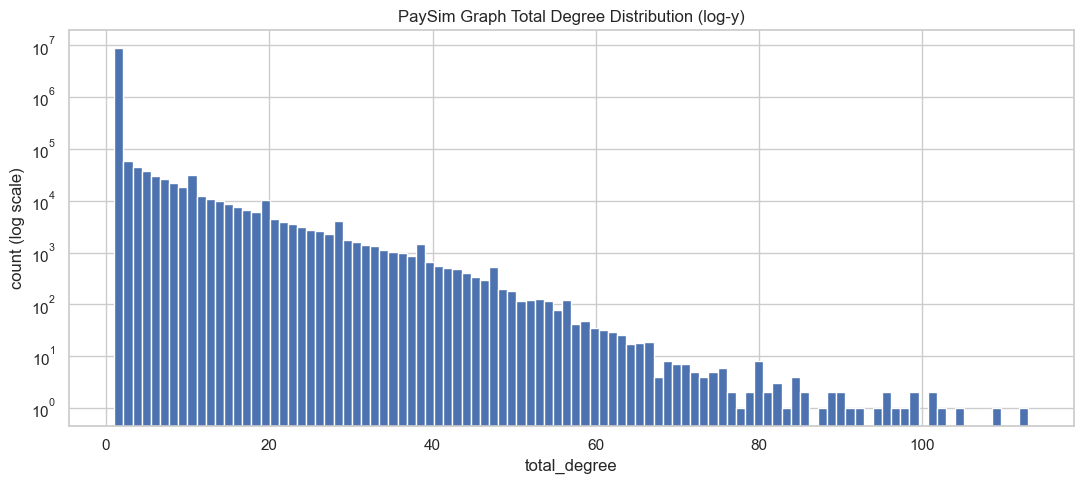

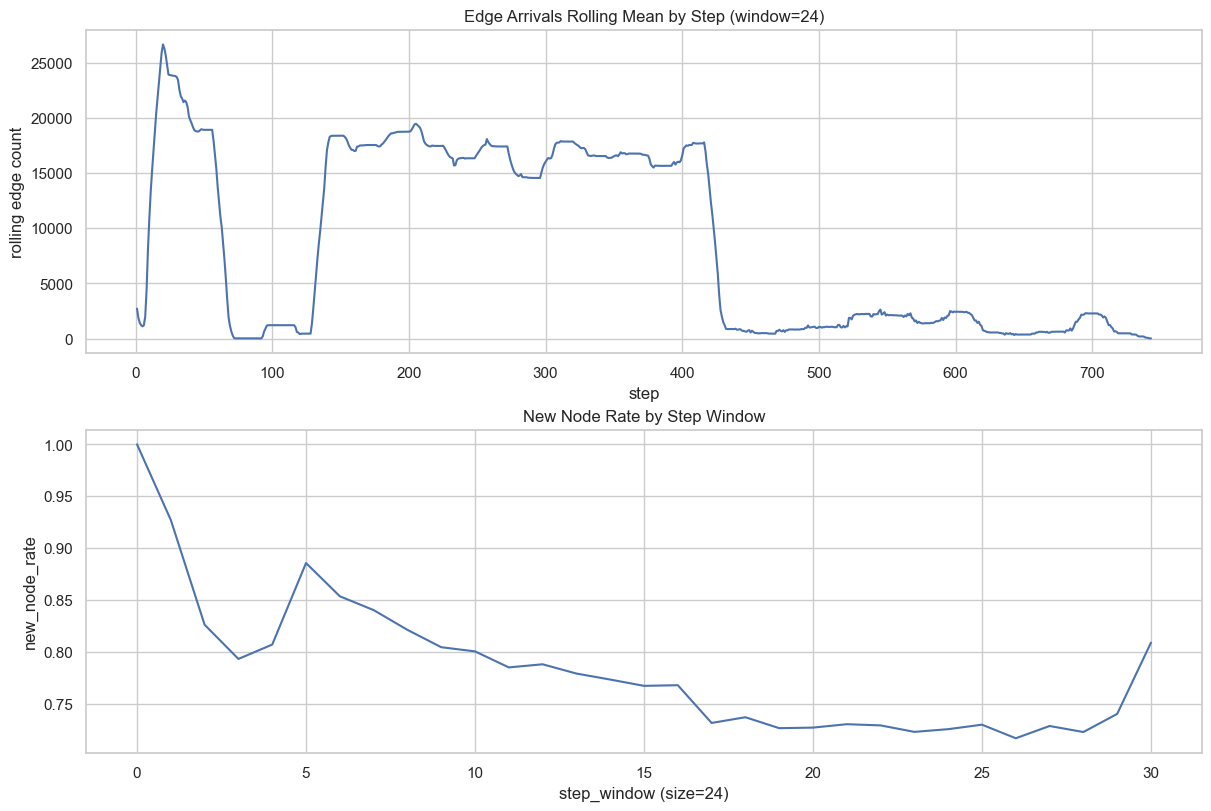

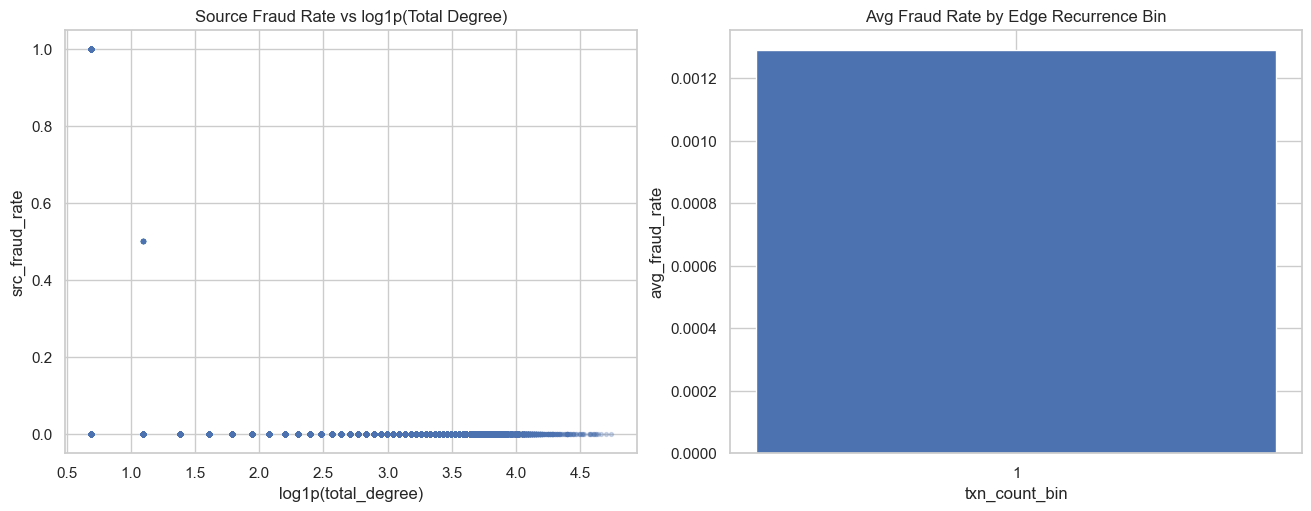

Graph-temporal EDA artifacts saved:
 - Topology overview, degree summary, hubs, active connected components
 - Edge arrivals, inter-event gap summary, node churn by window
 - Temporal leakage checks for nodes and edge-pairs
 - Pair stats, repeated/reciprocal motif summaries
 - Node fraud diagnostics and edge recurrence-vs-fraud table


In [8]:
# Graph-oriented EDA for temporal GNN readiness
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components

# Keep original raw frame columns for graph checks
edges = df[['nameOrig', 'nameDest', 'step', 'type', 'amount', 'isFraud']].copy()
edges = edges.rename(columns={'nameOrig': 'src', 'nameDest': 'dst'})

# -----------------------------------------------------------------------------
# 1) Graph topology EDA
# -----------------------------------------------------------------------------
edge_count = len(edges)
node_ids = pd.Index(edges['src']).append(pd.Index(edges['dst'])).unique()
node_count = len(node_ids)

out_degree = edges.groupby('src').size().rename('out_degree')
in_degree = edges.groupby('dst').size().rename('in_degree')

degree_table = pd.DataFrame(index=node_ids)
degree_table = degree_table.join(out_degree, how='left').join(in_degree, how='left').fillna(0)
degree_table['total_degree'] = degree_table['in_degree'] + degree_table['out_degree']

# Hub accounts by total degree
hub_accounts = degree_table.sort_values('total_degree', ascending=False).head(50).reset_index()
hub_accounts = hub_accounts.rename(columns={'index': 'account_id'})
hub_accounts.to_csv(EDA_TABLES / 'paysim_graph_hub_accounts_top50.csv', index=False)

# Degree summary
degree_summary = degree_table[['in_degree', 'out_degree', 'total_degree']].describe().T
degree_summary.to_csv(EDA_TABLES / 'paysim_graph_degree_summary.csv')

# Connected components on active subgraph for tractability
active_threshold = 10
active_nodes = degree_table.loc[degree_table['total_degree'] >= active_threshold].index
active_edges = edges[edges['src'].isin(active_nodes) & edges['dst'].isin(active_nodes)][['src', 'dst']].copy()

comp_result = {
    'active_degree_threshold': active_threshold,
    'active_node_count': int(len(active_nodes)),
    'active_edge_count': int(len(active_edges)),
    'connected_components': pd.NA,
    'largest_component_size': pd.NA,
}

if len(active_edges) > 0 and len(active_nodes) > 0:
    node_to_idx = {n: i for i, n in enumerate(active_nodes)}
    r = active_edges['src'].map(node_to_idx).to_numpy()
    c = active_edges['dst'].map(node_to_idx).to_numpy()
    data = np.ones(len(active_edges), dtype=np.int8)
    adj = coo_matrix((data, (r, c)), shape=(len(active_nodes), len(active_nodes)))
    n_components, labels = connected_components(csgraph=adj, directed=False, return_labels=True)
    comp_sizes = pd.Series(labels).value_counts()
    comp_result['connected_components'] = int(n_components)
    comp_result['largest_component_size'] = int(comp_sizes.max())

component_summary = pd.DataFrame([comp_result])
component_summary.to_csv(EDA_TABLES / 'paysim_graph_connected_components_active.csv', index=False)

# Topology overview
topology_overview = pd.DataFrame([
    {
        'node_count': int(node_count),
        'edge_count': int(edge_count),
        'graph_density_directed': float(edge_count / max(node_count * max(node_count - 1, 1), 1)),
        'active_node_count_deg_ge_10': int(len(active_nodes)),
        'active_edge_count_deg_ge_10': int(len(active_edges)),
    }
])
topology_overview.to_csv(EDA_TABLES / 'paysim_graph_topology_overview.csv', index=False)

# Degree distribution plot (log scale)
plt.figure(figsize=(11, 5))
plt.hist(degree_table['total_degree'].values, bins=100, log=True)
plt.title('PaySim Graph Total Degree Distribution (log-y)')
plt.xlabel('total_degree')
plt.ylabel('count (log scale)')
plt.tight_layout()
plt.savefig(EDA_FIGURES / 'paysim_graph_degree_distribution.png', dpi=140)
plt.show()

# -----------------------------------------------------------------------------
# 2) Temporal graph dynamics EDA
# -----------------------------------------------------------------------------
# Edge arrivals by step
edge_arrivals = edges.groupby('step', as_index=False).size().rename(columns={'size': 'edge_count'})
edge_arrivals['edge_count_rolling_24'] = edge_arrivals['edge_count'].rolling(24, min_periods=1).mean()
edge_arrivals.to_csv(EDA_TABLES / 'paysim_graph_edge_arrivals_by_step.csv', index=False)

# Inter-event times per source node (step gaps)
src_sorted = edges.sort_values(['src', 'step'])[['src', 'step']].copy()
src_sorted['step_gap'] = src_sorted.groupby('src')['step'].diff()
step_gap_summary = src_sorted['step_gap'].dropna().describe(percentiles=[0.5, 0.9, 0.95, 0.99]).to_frame('step_gap')
step_gap_summary.to_csv(EDA_TABLES / 'paysim_graph_interevent_gap_summary.csv')

# Churn/new-node rate by fixed step windows
window_size = 24
edges['step_window'] = ((edges['step'] - 1) // window_size).astype(int)

window_nodes = (
    edges.groupby('step_window')
    .apply(lambda x: pd.Index(x['src']).append(pd.Index(x['dst'])).unique(), include_groups=False)
)

seen = set()
churn_rows = []
for w, nodes in window_nodes.items():
    curr = set(nodes.tolist())
    new_nodes = curr - seen
    retained_nodes = curr & seen
    churn_rows.append({
        'step_window': int(w),
        'node_count': int(len(curr)),
        'new_node_count': int(len(new_nodes)),
        'retained_node_count': int(len(retained_nodes)),
        'new_node_rate': float(len(new_nodes) / max(len(curr), 1)),
    })
    seen |= curr

node_churn = pd.DataFrame(churn_rows)
node_churn.to_csv(EDA_TABLES / 'paysim_graph_node_churn_by_window.csv', index=False)

# Temporal dynamics figure
fig, axes = plt.subplots(2, 1, figsize=(12, 8), constrained_layout=True)
axes[0].plot(edge_arrivals['step'], edge_arrivals['edge_count_rolling_24'])
axes[0].set_title('Edge Arrivals Rolling Mean by Step (window=24)')
axes[0].set_xlabel('step')
axes[0].set_ylabel('rolling edge count')

axes[1].plot(node_churn['step_window'], node_churn['new_node_rate'])
axes[1].set_title('New Node Rate by Step Window')
axes[1].set_xlabel(f'step_window (size={window_size})')
axes[1].set_ylabel('new_node_rate')

plt.savefig(EDA_FIGURES / 'paysim_graph_temporal_dynamics.png', dpi=140)
plt.show()

# -----------------------------------------------------------------------------
# 3) Edge-label leakage checks for temporal split
# -----------------------------------------------------------------------------
train_edges = edges.loc[edges['step'] <= split_step].copy()
test_edges = edges.loc[edges['step'] > split_step].copy()

train_nodes = set(pd.Index(train_edges['src']).append(pd.Index(train_edges['dst'])).unique().tolist())
test_nodes = set(pd.Index(test_edges['src']).append(pd.Index(test_edges['dst'])).unique().tolist())
node_overlap = train_nodes & test_nodes

train_pairs = set(zip(train_edges['src'], train_edges['dst']))
test_pairs = set(zip(test_edges['src'], test_edges['dst']))
edge_pair_overlap = train_pairs & test_pairs

leakage_summary = pd.DataFrame([
    {
        'split_step': int(split_step),
        'train_node_count': int(len(train_nodes)),
        'test_node_count': int(len(test_nodes)),
        'overlap_node_count': int(len(node_overlap)),
        'overlap_node_rate_test': float(len(node_overlap) / max(len(test_nodes), 1)),
        'train_edge_pair_count': int(len(train_pairs)),
        'test_edge_pair_count': int(len(test_pairs)),
        'overlap_edge_pair_count': int(len(edge_pair_overlap)),
        'overlap_edge_pair_rate_test': float(len(edge_pair_overlap) / max(len(test_pairs), 1)),
    }
])
leakage_summary.to_csv(EDA_TABLES / 'paysim_graph_temporal_leakage_checks.csv', index=False)

# -----------------------------------------------------------------------------
# 4) Relation-level motifs / repeated paths
# -----------------------------------------------------------------------------
pair_stats = (
    edges.groupby(['src', 'dst'], as_index=False)
    .agg(
        txn_count=('isFraud', 'size'),
        fraud_count=('isFraud', 'sum'),
        fraud_rate=('isFraud', 'mean'),
        step_min=('step', 'min'),
        step_max=('step', 'max'),
    )
)
pair_stats['is_repeated_pair'] = pair_stats['txn_count'] > 1
pair_stats.to_csv(EDA_TABLES / 'paysim_graph_pair_stats.csv', index=False)

repeated_pair_summary = pd.DataFrame([
    {
        'all_pairs': int(len(pair_stats)),
        'repeated_pairs': int(pair_stats['is_repeated_pair'].sum()),
        'repeated_pair_rate': float(pair_stats['is_repeated_pair'].mean()),
        'fraud_rate_all_pairs': float(pair_stats['fraud_rate'].mean()),
        'fraud_rate_repeated_pairs': float(pair_stats.loc[pair_stats['is_repeated_pair'], 'fraud_rate'].mean() if pair_stats['is_repeated_pair'].any() else 0.0),
    }
])
repeated_pair_summary.to_csv(EDA_TABLES / 'paysim_graph_repeated_pair_summary.csv', index=False)

# Reciprocal links motif: src->dst and dst->src both exist
pair_keys = set(zip(pair_stats['src'], pair_stats['dst']))
reciprocal_count = sum((dst, src) in pair_keys for src, dst in pair_keys)
reciprocal_count = reciprocal_count // 2

motif_summary = pd.DataFrame([
    {
        'reciprocal_pair_count': int(reciprocal_count),
        'pair_count_total': int(len(pair_keys)),
        'reciprocal_pair_rate': float(reciprocal_count / max(len(pair_keys), 1)),
    }
])
motif_summary.to_csv(EDA_TABLES / 'paysim_graph_motif_summary.csv', index=False)

# -----------------------------------------------------------------------------
# 5) Graph feature diagnostics vs fraud
# -----------------------------------------------------------------------------
# Node-level fraud diagnostics (source and destination perspectives)
src_fraud = edges.groupby('src', as_index=False).agg(
    out_degree=('src', 'size'),
    src_fraud_rate=('isFraud', 'mean'),
)
dst_fraud = edges.groupby('dst', as_index=False).agg(
    in_degree=('dst', 'size'),
    dst_fraud_rate=('isFraud', 'mean'),
)

node_diag = pd.merge(src_fraud, dst_fraud, left_on='src', right_on='dst', how='outer')
node_diag['account_id'] = node_diag['src'].fillna(node_diag['dst'])
node_diag = node_diag.drop(columns=['src', 'dst'])
node_diag['out_degree'] = node_diag['out_degree'].fillna(0)
node_diag['in_degree'] = node_diag['in_degree'].fillna(0)
node_diag['src_fraud_rate'] = node_diag['src_fraud_rate'].fillna(0)
node_diag['dst_fraud_rate'] = node_diag['dst_fraud_rate'].fillna(0)
node_diag['total_degree'] = node_diag['out_degree'] + node_diag['in_degree']
node_diag.to_csv(EDA_TABLES / 'paysim_graph_node_fraud_diagnostics.csv', index=False)

# Edge recurrence vs fraud
pair_diag = pair_stats.copy()
pair_diag['txn_count_bin'] = pd.cut(
    pair_diag['txn_count'],
    bins=[0, 1, 2, 5, 10, 50, np.inf],
    labels=['1', '2', '3-5', '6-10', '11-50', '50+'],
    include_lowest=True,
)
recurrence_vs_fraud = (
    pair_diag.groupby('txn_count_bin', as_index=False)
    .agg(
        pair_count=('txn_count', 'size'),
        avg_fraud_rate=('fraud_rate', 'mean'),
        avg_txn_count=('txn_count', 'mean'),
    )
)
recurrence_vs_fraud.to_csv(EDA_TABLES / 'paysim_graph_edge_recurrence_vs_fraud.csv', index=False)

# Diagnostics figure
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

axes[0].scatter(
    np.log1p(node_diag['total_degree']),
    node_diag['src_fraud_rate'],
    s=8,
    alpha=0.25,
)
axes[0].set_title('Source Fraud Rate vs log1p(Total Degree)')
axes[0].set_xlabel('log1p(total_degree)')
axes[0].set_ylabel('src_fraud_rate')

axes[1].bar(recurrence_vs_fraud['txn_count_bin'].astype(str), recurrence_vs_fraud['avg_fraud_rate'])
axes[1].set_title('Avg Fraud Rate by Edge Recurrence Bin')
axes[1].set_xlabel('txn_count_bin')
axes[1].set_ylabel('avg_fraud_rate')

plt.savefig(EDA_FIGURES / 'paysim_graph_diagnostics.png', dpi=140)
plt.show()

print('Graph-temporal EDA artifacts saved:')
print(' - Topology overview, degree summary, hubs, active connected components')
print(' - Edge arrivals, inter-event gap summary, node churn by window')
print(' - Temporal leakage checks for nodes and edge-pairs')
print(' - Pair stats, repeated/reciprocal motif summaries')
print(' - Node fraud diagnostics and edge recurrence-vs-fraud table')

## Artifacts Generated
- data/processed/paysim/train_processed.csv
- data/processed/paysim/test_processed.csv
- data/features/paysim/X_train.csv
- data/features/paysim/y_train.csv
- data/features/paysim/X_test.csv
- notebooks/eda_outputs/tables/paysim_*.csv
- notebooks/eda_outputs/figures/paysim_*.png
- notebooks/eda_outputs/PAYSIM_EDA_SUMMARY_REPORT.txt